### Train Model

In [1]:
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
import torch
from torch.utils.data import  Dataset, DataLoader
from transformers import get_cosine_schedule_with_warmup
import av
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

/supernova/data/home/lillian/.conda/envs/chihuahua/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class BarkingDataset(Dataset):
    def __init__(self, root_dir, num_frames=16, transform=None):
        self.samples = []
        self.num_frames = num_frames
        self.transform = transform
        
        for label, class_name in enumerate(["Not_Barking", "Barking"]):
            class_dir = os.path.join(root_dir, class_name)
            for fname in os.listdir(class_dir):
                if fname.endswith((".mp4", ".avi", ".mov")):
                    self.samples.append((os.path.join(class_dir, fname), label))
    
    def load_video(self, path):
        container = av.open(path)
        frames = []
        
        for frame in container.decode(video=0):
            img = frame.to_ndarray(format="rgb24")
            frames.append(img)
        container.close()
        
        if len(frames) == 0:
            raise ValueError(f"No frames decoded from {path}")
        
        # If shorter than num_frames, pad by repeating last frame
        while len(frames) < self.num_frames:
            frames.append(frames[-1])
        
        # Sample num_frames evenly
        total = len(frames)
        indices = np.linspace(0, total - 1, self.num_frames, dtype=int)
        frames = [frames[i] for i in indices]
        
        return np.stack(frames)  # always [num_frames, H, W, 3]
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        frames = self.load_video(path)  # [T, H, W, 3]
        
        # Convert to tensor [T, C, H, W], normalize
        frames = torch.tensor(frames).permute(0, 3, 1, 2).float() / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        frames = (frames - mean) / std
        
        # Resize to 224x224
        frames = torch.nn.functional.interpolate(frames, size=(224, 224), mode="bilinear", align_corners=False)
        
        return {"pixel_values": frames, "labels": torch.tensor(label)}


# Create datasets
train_dataset = BarkingDataset("files/dataset/train", num_frames=16)
val_dataset   = BarkingDataset("files/dataset/val",   num_frames=16)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} clips, Val: {len(val_dataset)} clips")

Train: 360 clips, Val: 91 clips


In [3]:
model = VideoMAEForVideoClassification.from_pretrained(
    "MCG-NJU/videomae-base-finetuned-kinetics",  # Kinetics pretrain
    num_labels=2,
    ignore_mismatched_sizes=True,  # replaces the Kinetics 400-class head with binary class head
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `400`.
Loading weights: 100%|██████████| 162/162 [00:00<00:00, 12510.86it/s]
[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
videomae.encoder.layer.{0...11}.attention.attention.q_bias     | UNEXPECTED |                                                                                         
videomae.encoder.layer.{0...11}.attention.attention.v_bias     | UNEXPECTED |                                                                                         
videomae.encoder.layer.{0...11}.attention.attention.val

In [4]:
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze just the classification head
for param in model.classifier.parameters():
    param.requires_grad = True

# Optionally unfreeze last N transformer blocks
N = 2  # Tune
for block in model.videomae.encoder.layer[-N:]:
    for param in block.parameters():
        param.requires_grad = True

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Hyperparameters for 500 clips
LR = 1e-4          # Lower than typical because mostly frozen
EPOCHS = 15        # Small dataset trains fast
BATCH_SIZE = 8     # VideoMAE is memory hungry, use gradient accumulation if needed
WARMUP_EPOCHS = 5

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.05
)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_EPOCHS * len(train_loader),
    num_training_steps=EPOCHS * len(train_loader)
)

train_losses = []
val_losses = []
val_accs = []
aucs = []

best_auc = 0

best_val_loss = float("inf")
patience = 5
epochs_no_improve = 0

# Training
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)  # [B, T, C, H, W]
        labels = batch["labels"].to(device)              # [B]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    correct = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(pixel_values=pixel_values, labels=labels)

            val_loss += outputs.loss.item()
            probs = torch.softmax(outputs.logits, dim=-1)[:, 1]
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / len(val_dataset)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float("nan")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  ↑ best val loss, model saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    aucs.append(auc)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f} | val_acc: {val_acc:.3f} | AUC: {auc:.3f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  ↑ new best AUC, model saved")

  ↑ best val loss, model saved
Epoch 1/15 | train_loss: 0.6803 | val_loss: 0.6733 | val_acc: 0.604 | AUC: 0.624
  ↑ new best AUC, model saved
  ↑ best val loss, model saved
Epoch 2/15 | train_loss: 0.6251 | val_loss: 0.6150 | val_acc: 0.626 | AUC: 0.729
  ↑ new best AUC, model saved
  ↑ best val loss, model saved
Epoch 3/15 | train_loss: 0.5132 | val_loss: 0.6039 | val_acc: 0.692 | AUC: 0.754
  ↑ new best AUC, model saved
Epoch 4/15 | train_loss: 0.3593 | val_loss: 0.6795 | val_acc: 0.714 | AUC: 0.792
  ↑ new best AUC, model saved
Epoch 5/15 | train_loss: 0.2375 | val_loss: 0.6306 | val_acc: 0.725 | AUC: 0.809
  ↑ new best AUC, model saved
Epoch 6/15 | train_loss: 0.0795 | val_loss: 0.7820 | val_acc: 0.725 | AUC: 0.822
  ↑ new best AUC, model saved
Epoch 7/15 | train_loss: 0.0226 | val_loss: 1.0703 | val_acc: 0.769 | AUC: 0.821
Early stopping at epoch 8


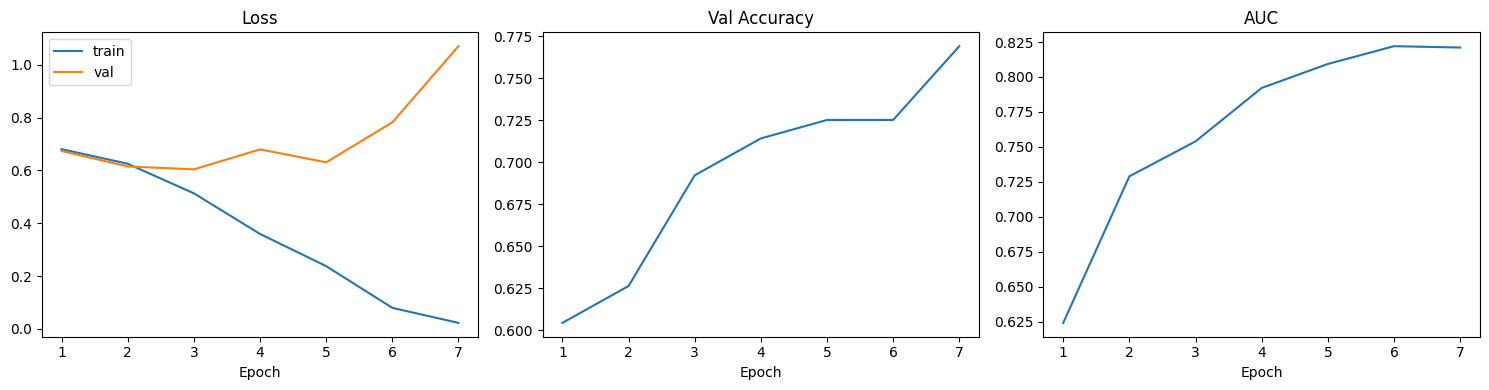

In [8]:
# --- PLOT after training ---
epochs = range(1, epoch + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, train_losses, label="train")
axes[0].plot(epochs, val_losses, label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, val_accs)
axes[1].set_title("Val Accuracy")
axes[1].set_xlabel("Epoch")

axes[2].plot(epochs, aucs)
axes[2].set_title("AUC")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [ ]:
print(auc)

### Dataset

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil

ROOT = Path("processed")      # folder containing 79897_bark_003/, etc.
OUT = Path("dataset")

examples = {}

for sample_dir in ROOT.iterdir():
    if not sample_dir.is_dir():
        continue

    csv_path = sample_dir / "training_windows.csv"
    if not csv_path.exists():
        continue

    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        crop = sample_dir / row["crop_path"]      # e.g. crops/foo_track_0.mp4

        if not crop.exists():
            continue

        # Only keep one entry per crop
        examples.setdefault(
            crop,
            row["label_text"]
        )

files = list(examples.keys())
labels = list(examples.values())

print(f"Found {len(files)} unique clips.")
print(pd.Series(labels).value_counts())

train_files, val_files, train_labels, val_labels = train_test_split(
    files,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

for split, split_files, split_labels in [
    ("train", train_files, train_labels),
    ("val", val_files, val_labels),
]:
    for src, label in zip(split_files, split_labels):
        dst = OUT / split / label
        dst.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst / src.name)

print("Done.")